       age          job   marital  education default  balance housing loan  \
0       58   management   married   tertiary      no     2143     yes   no   
8       58      retired   married    primary      no      121     yes   no   
12      53   technician   married  secondary      no        6     yes   no   
13      58   technician   married    unknown      no       71     yes   no   
14      57     services   married  secondary      no      162     yes   no   
...    ...          ...       ...        ...     ...      ...     ...  ...   
45204   73      retired   married  secondary      no     2850      no   no   
45206   51   technician   married   tertiary      no      825      no   no   
45207   71      retired  divorced    primary      no     1729      no   no   
45208   72      retired   married  secondary      no     5715      no   no   
45209   57  blue-collar   married  secondary      no      668      no   no   

       day month  campaign  pdays  previous poutcome    y  
0  

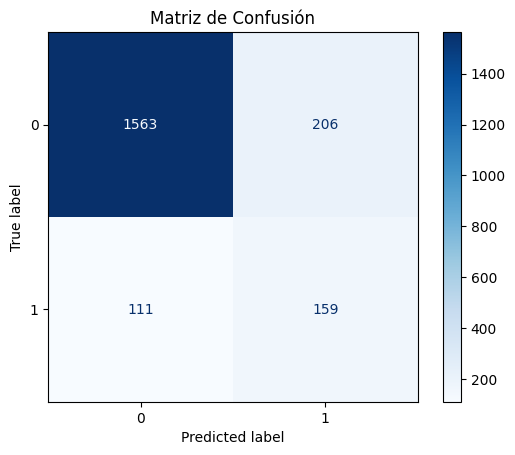

              precision    recall  f1-score   support

           0       0.93      0.88      0.91      1769
           1       0.44      0.59      0.50       270

    accuracy                           0.84      2039
   macro avg       0.68      0.74      0.70      2039
weighted avg       0.87      0.84      0.85      2039



In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt  # Asegúrate de importar matplotlib para la matriz de confusión

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')
df = df[(df['age'] >= 50) & (df['age'] <= 100)] 

#df = df[(df['age'] >= 50) & (df['age'] <= 100)] 0.60
df = df.drop(columns=['duration'])
df = df.drop(columns=['contact'])

print(df)
# convertir
cat_int_feats = ['default', 'housing', 'loan',  'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes  

df['y'] = df['y'].map({'no': 0, 'yes': 1})  

feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y") 
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

batch_size = 32
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])  
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))  
    normalizer.adapt(feature_ds)  
    encoded_feature = normalizer(feature)  
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")  
    feature_ds = dataset.map(lambda x, y: x[name])  
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))  
    lookup.adapt(feature_ds)  
    encoded_feature = lookup(feature)  
    return encoded_feature

inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds))

all_feats = tf.concat(feats_encoded, axis=1)
model_layers = keras.layers.Dense(32, activation='relu')(all_feats)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)

# MODELO
model = keras.Model(inputs, model_layers)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Eliminar o comentar la línea de visualización del modelo
# keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

model.fit(train_ds, epochs=50, validation_data=val_ds)

test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

y_true = []
y_pred = []

for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.2).astype(int).flatten())  

# MATRIZ DE CONFUCIÓN
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

print(report)




       age          job   marital  education default  balance housing loan  \
0       58   management   married   tertiary      no     2143     yes   no   
8       58      retired   married    primary      no      121     yes   no   
12      53   technician   married  secondary      no        6     yes   no   
13      58   technician   married    unknown      no       71     yes   no   
14      57     services   married  secondary      no      162     yes   no   
...    ...          ...       ...        ...     ...      ...     ...  ...   
45204   73      retired   married  secondary      no     2850      no   no   
45206   51   technician   married   tertiary      no      825      no   no   
45207   71      retired  divorced    primary      no     1729      no   no   
45208   72      retired   married  secondary      no     5715      no   no   
45209   57  blue-collar   married  secondary      no      668      no   no   

       day month  campaign  pdays  previous poutcome    y  
0  

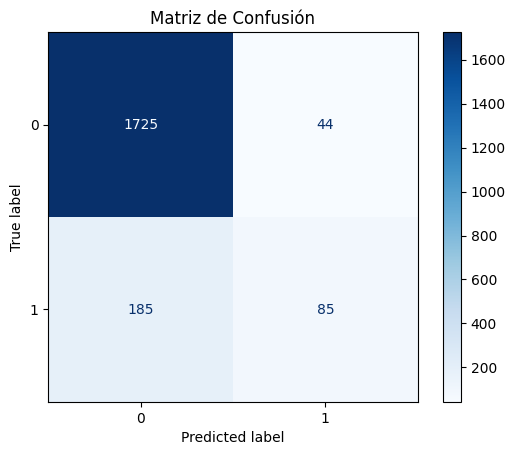

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1769
           1       0.66      0.31      0.43       270

    accuracy                           0.89      2039
   macro avg       0.78      0.64      0.68      2039
weighted avg       0.87      0.89      0.87      2039



In [69]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt  # Asegúrate de importar matplotlib para la matriz de confusión

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')
df = df[(df['age'] >= 50) & (df['age'] <= 100)] 

#df = df[(df['age'] >= 50) & (df['age'] <= 100)] 0.60
df = df.drop(columns=['duration'])
df = df.drop(columns=['contact'])

print(df)
# convertir
cat_int_feats =['month','job', 'poutcome', 'education', 'marital','housing', 'loan', 'default']
num_feats = ['age', 'balance', 'campaign', 'pdays', 'day',  'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes  

df['y'] = df['y'].map({'no': 0, 'yes': 1})  

feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y") 
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

batch_size = 32
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])  
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))  
    normalizer.adapt(feature_ds)  
    encoded_feature = normalizer(feature)  
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")  
    feature_ds = dataset.map(lambda x, y: x[name])  
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))  
    lookup.adapt(feature_ds)  
    encoded_feature = lookup(feature)  
    return encoded_feature

inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds))

all_feats = tf.concat(feats_encoded, axis=1)
model_layers = keras.layers.Dense(64, activation='relu')(all_feats)
model_layers = keras.layers.Dropout(0.5)(model_layers)  # Añadir dropout para evitar sobreajuste
model_layers = keras.layers.Dense(32, activation='relu')(model_layers)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)

# MODELO
model = keras.Model(inputs, model_layers)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Eliminar o comentar la línea de visualización del modelo
# keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

model.fit(train_ds, epochs=50, validation_data=val_ds)

test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

y_true = []
y_pred = []

for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())  

# MATRIZ DE CONFUCIÓN
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

print(report)




       age           job  marital  education default  balance housing loan  \
1       44    technician   single  secondary      no       29     yes   no   
2       33  entrepreneur  married  secondary      no        2     yes  yes   
3       47   blue-collar  married    unknown      no     1506     yes   no   
4       33       unknown   single    unknown      no        1      no   no   
5       35    management  married   tertiary      no      231     yes   no   
...    ...           ...      ...        ...     ...      ...     ...  ...   
45200   38    technician  married  secondary      no      557     yes   no   
45202   34        admin.   single  secondary      no      557      no   no   
45203   23       student   single   tertiary      no      113      no   no   
45205   25    technician   single  secondary      no      505      no  yes   
45210   37  entrepreneur  married  secondary      no     2971      no   no   

       day month  campaign  pdays  previous poutcome    y  
1  

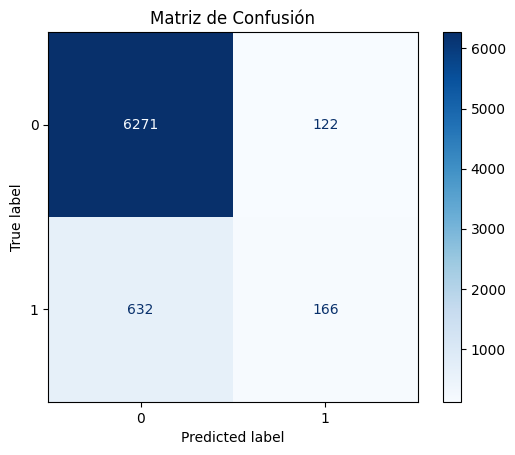

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      6393
           1       0.58      0.21      0.31       798

    accuracy                           0.90      7191
   macro avg       0.74      0.59      0.62      7191
weighted avg       0.87      0.90      0.87      7191



In [70]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt  # Asegúrate de importar matplotlib para la matriz de confusión

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')
df = df[(df['age'] >= 18) & (df['age'] <= 50)] 

#df = df[(df['age'] >= 50) & (df['age'] <= 100)] 0.60
df = df.drop(columns=['duration'])
df = df.drop(columns=['contact'])

print(df)
# convertir
cat_int_feats =['month','job', 'poutcome', 'education', 'marital','housing', 'loan', 'default']
num_feats = ['age', 'balance', 'campaign', 'pdays', 'day',  'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes  

df['y'] = df['y'].map({'no': 0, 'yes': 1})  

feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y") 
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

batch_size = 32
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])  
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))  
    normalizer.adapt(feature_ds)  
    encoded_feature = normalizer(feature)  
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")  
    feature_ds = dataset.map(lambda x, y: x[name])  
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))  
    lookup.adapt(feature_ds)  
    encoded_feature = lookup(feature)  
    return encoded_feature

inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds))

all_feats = tf.concat(feats_encoded, axis=1)
model_layers = keras.layers.Dense(64, activation='relu')(all_feats)
model_layers = keras.layers.Dropout(0.5)(model_layers)  # Añadir dropout para evitar sobreajuste
model_layers = keras.layers.Dense(32, activation='relu')(model_layers)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)

# MODELO
model = keras.Model(inputs, model_layers)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Eliminar o comentar la línea de visualización del modelo
# keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

model.fit(train_ds, epochs=50, validation_data=val_ds)

test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

y_true = []
y_pred = []

for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())  

# MATRIZ DE CONFUCIÓN
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

print(report)




Epoch 1/50
351/351 [==============================] - 3s 4ms/step - loss: 0.5132 - accuracy: 0.7607 - val_loss: 0.5144 - val_accuracy: 0.7315
Epoch 2/50
351/351 [==============================] - 1s 3ms/step - loss: 0.4341 - accuracy: 0.8062 - val_loss: 0.5164 - val_accuracy: 0.7498
Epoch 3/50
351/351 [==============================] - 1s 3ms/step - loss: 0.4239 - accuracy: 0.8100 - val_loss: 0.5025 - val_accuracy: 0.7572
Epoch 4/50
351/351 [==============================] - 1s 3ms/step - loss: 0.4170 - accuracy: 0.8135 - val_loss: 0.4619 - val_accuracy: 0.7805
Epoch 5/50
351/351 [==============================] - 1s 3ms/step - loss: 0.4115 - accuracy: 0.8158 - val_loss: 0.4668 - val_accuracy: 0.7805
Epoch 6/50
351/351 [==============================] - 1s 3ms/step - loss: 0.4066 - accuracy: 0.8179 - val_loss: 0.4847 - val_accuracy: 0.7633
Epoch 7/50
351/351 [==============================] - 1s 3ms/step - loss: 0.4013 - accuracy: 0.8213 - val_loss: 0.4902 - val_accuracy: 0.7597
Epoch 

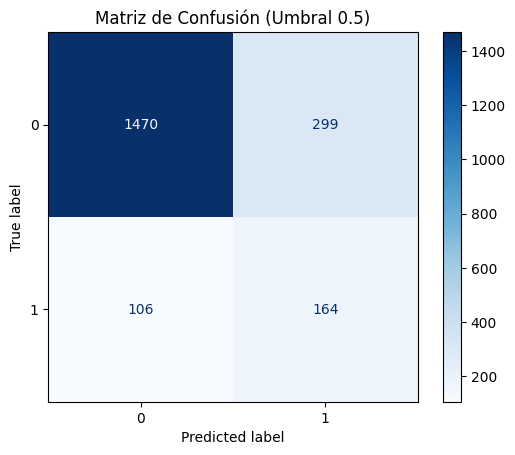

In [68]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')
df = df[(df['age'] >= 50) & (df['age'] <= 100)] 
df = df.drop(columns=['duration', 'contact'])  # Eliminar columnas innecesarias

# Convertir las características categóricas
cat_int_feats =['month','job', 'poutcome', 'education', 'marital','housing', 'loan', 'default']
num_feats = ['age', 'balance', 'campaign', 'pdays', 'day',  'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes  

df['y'] = df['y'].map({'no': 0, 'yes': 1})  

# Reorganizar el DataFrame
feats_ordered = cat_int_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir en conjuntos de entrenamiento, validación y prueba
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Aplicar SMOTE solo en el conjunto de entrenamiento
X_train = train.drop('y', axis=1)
y_train = train['y']

smote = SMOTE(random_state=100)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Crear DataFrames con los datos balanceados
train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)
train_resampled['y'] = y_train_resampled

# Función para convertir DataFrame a TensorFlow Dataset
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y") 
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Crear datasets
train_ds = dataframe_to_dataset(train_resampled)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

batch_size = 32
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# Funciones de codificación para características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])  
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))  
    normalizer.adapt(feature_ds)  
    encoded_feature = normalizer(feature)  
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")  
    feature_ds = dataset.map(lambda x, y: x[name])  
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))  
    lookup.adapt(feature_ds)  
    encoded_feature = lookup(feature)  
    return encoded_feature

# Construir el modelo
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds))

all_feats = tf.concat(feats_encoded, axis=1)
model_layers = keras.layers.Dense(32, activation='relu')(all_feats)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)

# Modelo
model = keras.Model(inputs, model_layers)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento del modelo
model.fit(train_ds, epochs=50, validation_data=val_ds)

# Evaluar el modelo
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Obtener las predicciones
y_true = []
predictions = []

for x, y in test_ds:
    y_true.extend(y.numpy())
    preds = model.predict(x)
    predictions.extend(preds.flatten())

# Evaluación con diferentes umbrales
for threshold in [0.1, 0.5, 0.6, 0.7, 0.8]:
    y_pred = (np.array(predictions) > threshold).astype(int)
    report = classification_report(y_true, y_pred)
    print(f"Resultados para umbral {threshold}:")
    print(report)

# MATRIZ DE CONFUSIÓN para el umbral 0.5
y_pred_final = (np.array(predictions) > 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Umbral 0.5)')
plt.show()



## Oversampling

y
0    5604
1    5604
Name: count, dtype: int64
Epoch 1/50
351/351 [==============================] - 1s 2ms/step - loss: 0.4784 - accuracy: 0.7867 - val_loss: 0.4971 - val_accuracy: 0.7597
Epoch 2/50
351/351 [==============================] - 0s 1ms/step - loss: 0.3999 - accuracy: 0.8268 - val_loss: 0.4520 - val_accuracy: 0.7952
Epoch 3/50
351/351 [==============================] - 0s 1ms/step - loss: 0.3894 - accuracy: 0.8350 - val_loss: 0.4503 - val_accuracy: 0.7934
Epoch 4/50
351/351 [==============================] - 0s 1ms/step - loss: 0.3829 - accuracy: 0.8376 - val_loss: 0.4660 - val_accuracy: 0.7823
Epoch 5/50
351/351 [==============================] - 0s 1ms/step - loss: 0.3788 - accuracy: 0.8409 - val_loss: 0.4511 - val_accuracy: 0.7971
Epoch 6/50
351/351 [==============================] - 0s 1ms/step - loss: 0.3734 - accuracy: 0.8435 - val_loss: 0.4807 - val_accuracy: 0.7866
Epoch 7/50
351/351 [==============================] - 0s 1ms/step - loss: 0.3704 - accuracy: 0.8451 

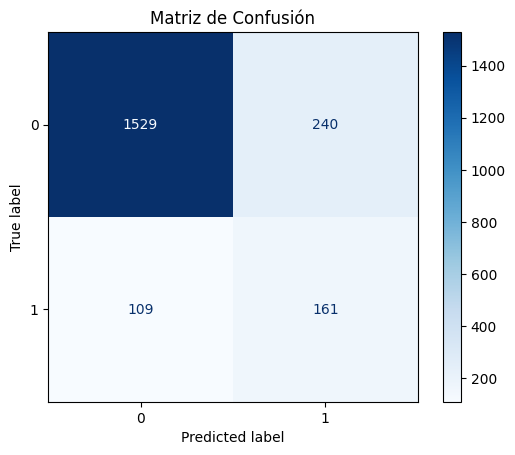

              precision    recall  f1-score   support

           0       0.93      0.86      0.90      1769
           1       0.40      0.60      0.48       270

    accuracy                           0.83      2039
   macro avg       0.67      0.73      0.69      2039
weighted avg       0.86      0.83      0.84      2039



In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')
df = df[(df['age'] >= 50) & (df['age'] <= 100)]
# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTE()
#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características codificadas
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(32, activation='relu')(all_feats)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)
model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)


## DownSampling

y
0    3413
1    3413
Name: count, dtype: int64
Epoch 1/50
214/214 [==============================] - 6s 13ms/step - loss: 0.6265 - accuracy: 0.6560 - val_loss: 0.5907 - val_accuracy: 0.6892
Epoch 2/50
214/214 [==============================] - 2s 8ms/step - loss: 0.5811 - accuracy: 0.6947 - val_loss: 0.5559 - val_accuracy: 0.7309
Epoch 3/50
214/214 [==============================] - 2s 8ms/step - loss: 0.5661 - accuracy: 0.7060 - val_loss: 0.5743 - val_accuracy: 0.7288
Epoch 4/50
214/214 [==============================] - 2s 8ms/step - loss: 0.5594 - accuracy: 0.7126 - val_loss: 0.5324 - val_accuracy: 0.7845
Epoch 5/50
214/214 [==============================] - 2s 8ms/step - loss: 0.5556 - accuracy: 0.7145 - val_loss: 0.5314 - val_accuracy: 0.7842
Epoch 6/50
214/214 [==============================] - 2s 8ms/step - loss: 0.5529 - accuracy: 0.7161 - val_loss: 0.5718 - val_accuracy: 0.7526
Epoch 7/50
214/214 [==============================] - 2s 8ms/step - loss: 0.5496 - accuracy: 0.7247

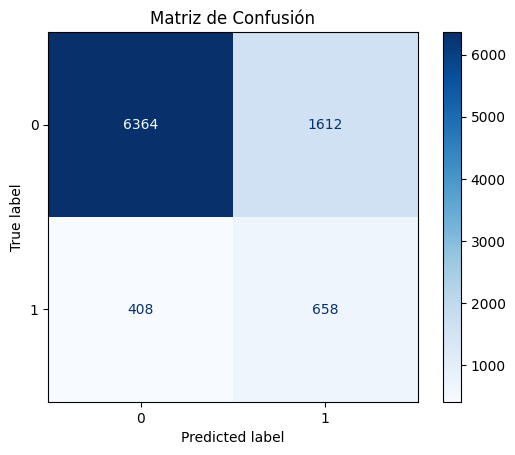

              precision    recall  f1-score   support

           0       0.94      0.80      0.86      7976
           1       0.29      0.62      0.39      1066

    accuracy                           0.78      9042
   macro avg       0.61      0.71      0.63      9042
weighted avg       0.86      0.78      0.81      9042



In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Downsampling para balancear las clases
class_0 = train[train['y'] == 0]
class_1 = train[train['y'] == 1]

class_0_downsampled = class_0.sample(len(class_1), random_state=100)


train_downsampled = pd.concat([class_0_downsampled, class_1])

# Verificar el balanceo
print(train_downsampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds_downsampled = dataframe_to_dataset(train_downsampled)
train_ds_downsampled = train_ds_downsampled.batch(32)
val_ds = dataframe_to_dataset(val).batch(32)
test_ds = dataframe_to_dataset(test).batch(32)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_downsampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_downsampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_downsampled))

# Concatenar todas las características codificadas
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(32, activation='relu')(all_feats)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)
model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados por downsampling
model.fit(train_ds_downsampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)


## Weights

y
0    25522
1     3413
Name: count, dtype: int64
Weight for class 0: 0.5668638821408981
Weight for class 1: 4.238939349545854
Epoch 1/50
905/905 [==============================] - 8s 6ms/step - loss: 0.5918 - accuracy: 0.7078 - val_loss: 0.5805 - val_accuracy: 0.7237
Epoch 2/50
905/905 [==============================] - 5s 5ms/step - loss: 0.5618 - accuracy: 0.7628 - val_loss: 0.5139 - val_accuracy: 0.8027
Epoch 3/50
905/905 [==============================] - 5s 5ms/step - loss: 0.5555 - accuracy: 0.7765 - val_loss: 0.5822 - val_accuracy: 0.7409
Epoch 4/50
905/905 [==============================] - 5s 5ms/step - loss: 0.5504 - accuracy: 0.7818 - val_loss: 0.5806 - val_accuracy: 0.7519
Epoch 5/50
905/905 [==============================] - 5s 5ms/step - loss: 0.5481 - accuracy: 0.7840 - val_loss: 0.5204 - val_accuracy: 0.8000
Epoch 6/50
905/905 [==============================] - 4s 5ms/step - loss: 0.5453 - accuracy: 0.7917 - val_loss: 0.5766 - val_accuracy: 0.7427
Epoch 7/50
905/905 [=

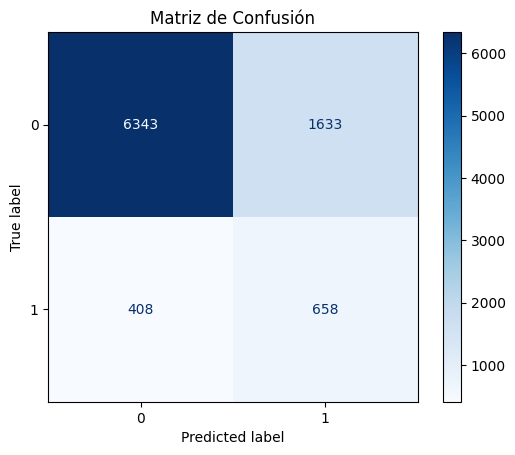

              precision    recall  f1-score   support

           0       0.94      0.80      0.86      7976
           1       0.29      0.62      0.39      1066

    accuracy                           0.77      9042
   macro avg       0.61      0.71      0.63      9042
weighted avg       0.86      0.77      0.81      9042



In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Verificar el desbalance en las clases
print(train['y'].value_counts())

# Convertir los conjuntos de datos a dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds = dataframe_to_dataset(train).batch(32)
val_ds = dataframe_to_dataset(val).batch(32)
test_ds = dataframe_to_dataset(test).batch(32)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds))

# Concatenar todas las características codificadas
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(32, activation='relu')(all_feats)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)
model = keras.Model(inputs, model_layers)

# Obtener las cantidades de cada clase en el conjunto de entrenamiento
count_class_0, count_class_1 = train['y'].value_counts()

# Calcular los pesos para las clases
total_samples = count_class_0 + count_class_1
weight_for_0 = (1 / count_class_0) * (total_samples / 2.0)
weight_for_1 = (1 / count_class_1) * (total_samples / 2.0)

# Definir los pesos de las clases
class_weight = {0: weight_for_0, 1: weight_for_1}
print(f"Weight for class 0: {weight_for_0}")
print(f"Weight for class 1: {weight_for_1}")

# Compilar el modelo con binary crossentropy como función de pérdida
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo aplicando los pesos para balancear las clases
model.fit(train_ds, epochs=50, validation_data=val_ds, class_weight=class_weight)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)


In [ ]:
#Dos clases altamente desbalanceadas. Solciones:
#1. Downsampling
#2. Oversampling
#3. Weights

In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from imblearn.over_sampling import BorderlineSMOTE, ADASYN

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = BorderlineSMOTE(random_state=42)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características codificadas
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(32, activation='relu')(all_feats)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)
model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación TEMAS DE CARACTERSITICAS, INCLUIR OTRAS CARACTERSITICAS, DIVEFERENTES MODELOS APRA DIFEERENTES POBLACIONES
print(report)


y
0    25522
1    25522
Name: count, dtype: int64
Epoch 1/50
1596/1596 [==============================] - 11s 5ms/step - loss: 0.4252 - accuracy: 0.8154 - val_loss: 0.4164 - val_accuracy: 0.8291
Epoch 2/50
1596/1596 [==============================] - 8s 5ms/step - loss: 0.3882 - accuracy: 0.8372 - val_loss: 0.4717 - val_accuracy: 0.7965
Epoch 3/50
1596/1596 [==============================] - 8s 5ms/step - loss: 0.3756 - accuracy: 0.8444 - val_loss: 0.4332 - val_accuracy: 0.8193
Epoch 4/50
1596/1596 [==============================] - 7s 4ms/step - loss: 0.3672 - accuracy: 0.8475 - val_loss: 0.4056 - val_accuracy: 0.8318
Epoch 5/50
1596/1596 [==============================] - 8s 4ms/step - loss: 0.3623 - accuracy: 0.8492 - val_loss: 0.4399 - val_accuracy: 0.8161
Epoch 6/50
1596/1596 [==============================] - 9s 5ms/step - loss: 0.3579 - accuracy: 0.8509 - val_loss: 0.4443 - val_accuracy: 0.8168
Epoch 7/50
1596/1596 [==============================] - 7s 4ms/step - loss: 0.3548 - 

KeyboardInterrupt: 

y
0    25522
1    25074
Name: count, dtype: int64
Epoch 1/50
1582/1582 [==============================] - 10s 5ms/step - loss: 0.4387 - accuracy: 0.8064 - val_loss: 0.4483 - val_accuracy: 0.8056
Epoch 2/50
1582/1582 [==============================] - 8s 4ms/step - loss: 0.4029 - accuracy: 0.8268 - val_loss: 0.4535 - val_accuracy: 0.8055
Epoch 3/50
1582/1582 [==============================] - 8s 4ms/step - loss: 0.3925 - accuracy: 0.8316 - val_loss: 0.4685 - val_accuracy: 0.7975
Epoch 4/50
1582/1582 [==============================] - 7s 4ms/step - loss: 0.3854 - accuracy: 0.8337 - val_loss: 0.4757 - val_accuracy: 0.7943
Epoch 5/50
1582/1582 [==============================] - 7s 4ms/step - loss: 0.3803 - accuracy: 0.8380 - val_loss: 0.4297 - val_accuracy: 0.8229
Epoch 6/50
1582/1582 [==============================] - 7s 4ms/step - loss: 0.3758 - accuracy: 0.8391 - val_loss: 0.4229 - val_accuracy: 0.8279
Epoch 7/50
1582/1582 [==============================] - 7s 4ms/step - loss: 0.3727 - 

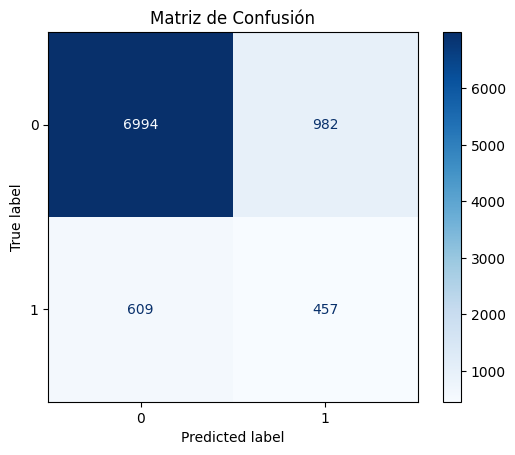

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      7976
           1       0.32      0.43      0.36      1066

    accuracy                           0.82      9042
   macro avg       0.62      0.65      0.63      9042
weighted avg       0.85      0.82      0.84      9042



In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from imblearn.over_sampling import BorderlineSMOTE, ADASYN

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']
# Revisar como modelo las categorias
# Valores Shap, cual variable esta impactando en que direcciòn 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

adasyn = ADASYN(random_state=42)


#smote = SMOTE(random_state=100)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características codificadas
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(32, activation='relu')(all_feats)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)
model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)


In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import shap

# Cargar los datos
df = pd.read_csv('bank-full.csv', sep=";")

# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Downsampling para balancear las clases
class_0 = train[train['y'] == 0]
class_1 = train[train['y'] == 1]

# Reducir el número de muestras de la clase mayoritaria (0) al número de la clase minoritaria (1)
class_0_downsampled = class_0.sample(len(class_1), random_state=100)

# Combinar ambas clases para formar un conjunto de datos balanceado
train_downsampled = pd.concat([class_0_downsampled, class_1])

# Verificar el balanceo
print(train_downsampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds_downsampled = dataframe_to_dataset(train_downsampled).batch(32)
val_ds = dataframe_to_dataset(val).batch(32)
test_ds = dataframe_to_dataset(test).batch(32)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_downsampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_downsampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_downsampled))

# Concatenar todas las características codificadas
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(32, activation='relu')(all_feats)
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)
model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados por downsampling
model.fit(train_ds_downsampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test


c:\Users\57301\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: 'bank-full.csv'